# EX 6A – Baseball Databank / Power BI

# CB23731 – DATA VISUALIZATION TECHNIQUES
## EXPT NO: 6A – DATA VISUALIZATION USING POWER BI
### Dataset: Baseball Databank

**Aim:** To import, transform, analyze, and visualize Baseball data using Power BI Desktop and create interactive dashboards and reports for decision-making.

This notebook documents the Power BI workflow and provides the prepared Baseball analysis used to build the dashboard. The Power BI report itself is created in Power BI Desktop.

### Algorithm
1. Start Power BI Desktop.
2. Import the Baseball Databank table using Get Data.
3. Check columns and clean data using Power Query.
4. Remove duplicate records and handle missing values.
5. Create calculated fields/measures.
6. Create bar, pie/donut, line and card visuals.
7. Add titles, labels, filters and slicers.
8. Arrange visuals into an interactive dashboard.
9. Analyze important patterns and save the Power BI report.

In [1]:
from pathlib import Path

def find_data(filename):
    candidates = [
        Path(filename),
        Path("data") / filename,
        Path("../data") / filename,
        Path("../../data") / filename,
        Path("/content") / filename,
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"{filename} not found. Upload the Baseball Databank CSV or keep it in the repository data folder.")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = find_data("Batting.csv")
df = pd.read_csv(file_path)
print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))
print("Duplicate rows:", df.duplicated().sum())

Dataset shape: (101332, 22)
Columns: ['playerID', 'yearID', 'stint', 'teamID', 'lgID', 'G', 'AB', 'R', 'H', '2B', '3B', 'HR', 'RBI', 'SB', 'CS', 'BB', 'SO', 'IBB', 'HBP', 'SH', 'SF', 'GIDP']
Duplicate rows: 0


In [2]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
playerID        0
yearID          0
stint           0
teamID          0
lgID          737
G               0
AB           5149
R            5149
H            5149
2B           5149
3B           5149
HR           5149
RBI          5573
SB           6449
CS          28603
BB           5149
SO          12987
IBB         41712
HBP          7959
SH          11487
SF          41181
GIDP        31257
dtype: int64


In [3]:
clean = df.copy()

for col in clean.select_dtypes(include=np.number).columns:
    clean[col] = clean[col].fillna(0)

for col in clean.select_dtypes(include=["object"]).columns:
    clean[col] = clean[col].fillna("Unknown")

print("Prepared shape:", clean.shape)
print("Remaining missing values:", int(clean.isnull().sum().sum()))

Prepared shape: (101332, 22)
Remaining missing values: 0


In [4]:
total_runs = clean["R"].sum()
total_players = clean["playerID"].nunique()
total_seasons = clean["yearID"].nunique()
total_records = len(clean)

print("Total Runs =", total_runs)
print("Total Players =", total_players)
print("Total Seasons =", total_seasons)
print("Total Player-Season Records =", total_records)

Total Runs = 1912795.0
Total Players = 18659
Total Seasons = 145
Total Player-Season Records = 101332


In [5]:
clean["total_runs"] = clean["R"]
season_runs = clean.groupby("yearID", as_index=False)["total_runs"].sum()
print(season_runs.to_string(index=False))

 yearID  total_runs
   1871      2659.0
   1872      3390.0
   1873      3580.0
   1874      3470.0
   1875      4234.0
   1876      3066.0
   1877      2040.0
   1878      1904.0
   1879      3409.0
   1880      3191.0
   1881      3426.0
   1882      6095.0
   1883      9030.0
   1884     16742.0
   1885      9292.0
   1886     11512.0
   1887     13414.0
   1888     10628.0
   1889     12986.0
   1890     19330.0
   1891     12667.0
   1892      9388.0
   1893     10315.0
   1894     11678.0
   1895     10482.0
   1896      9555.0
   1897      9520.0
   1898      9129.0
   1899      9647.0
   1900      5932.0
   1901     11073.0
   1902      9879.0
   1903      9888.0
   1904      9302.0
   1905      9636.0
   1906      8873.0
   1907      8692.0
   1908      8417.0
   1909      8794.0
   1910      9575.0
   1911     11161.0
   1912     11165.0
   1913      9960.0
   1914     14530.0
   1915     14213.0
   1916      8889.0
   1917      8950.0
   1918      7382.0
   1919      8668.0


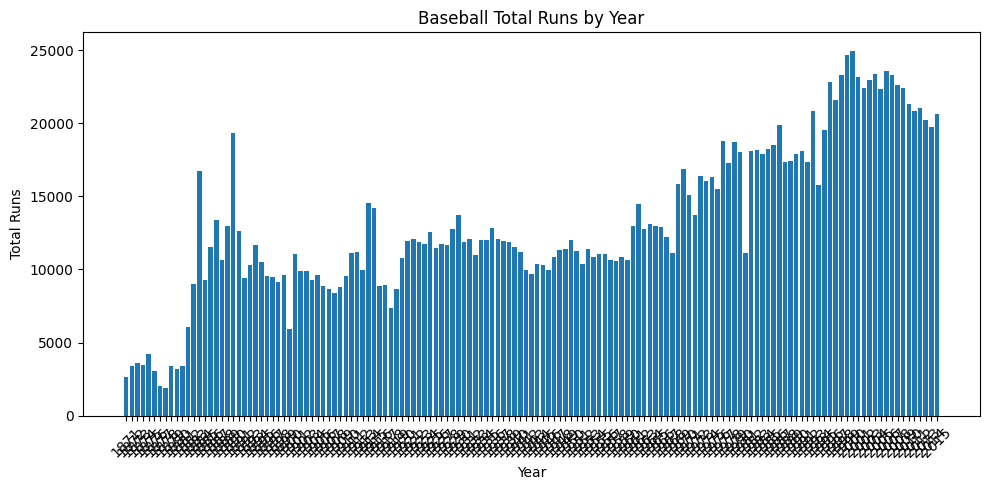

In [6]:
plt.figure(figsize=(10,5))
plt.bar(season_runs["yearID"].astype(str), season_runs["total_runs"])
plt.title("Baseball Total Runs by Year")
plt.xlabel("Year")
plt.ylabel("Total Runs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Experiment_6A_Baseball_Season_Line.png", dpi=150, bbox_inches="tight")
plt.show()

teamID
CHN    96003.0
PHI    89959.0
PIT    88658.0
SLN    86003.0
CIN    85970.0
NYA    85715.0
BOS    83309.0
DET    83222.0
CLE    81116.0
CHA    78221.0


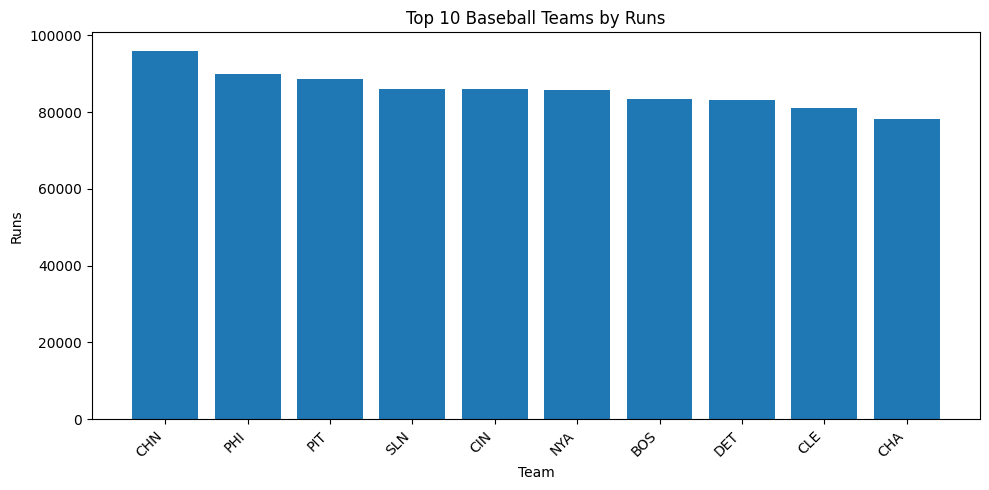

In [7]:
team_runs = clean.groupby("teamID")["R"].sum().sort_values(ascending=False).head(10)
print(team_runs.to_string())
plt.figure(figsize=(10,5))
plt.bar(team_runs.index, team_runs.values)
plt.title("Top 10 Baseball Teams by Runs")
plt.xlabel("Team")
plt.ylabel("Runs")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("Experiment_6A_Baseball_Team_Bar.png", dpi=150, bbox_inches="tight")
plt.show()

Hits            3776303.0
Home Runs        283673.0
RBI             1720326.0
Stolen Bases     299658.0


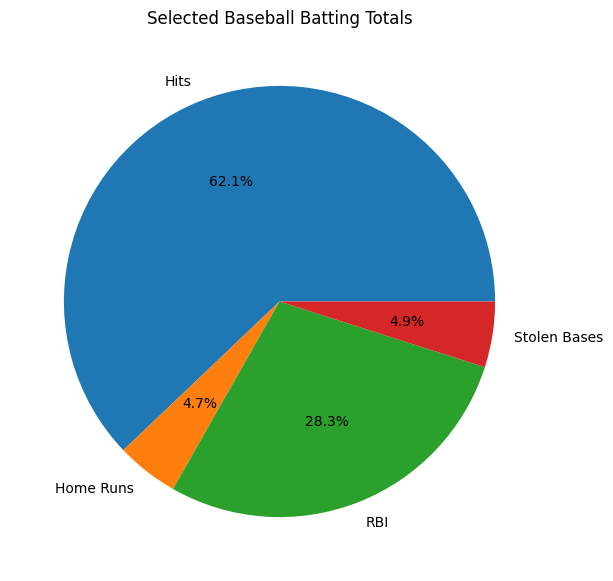

In [8]:
components = pd.Series({"Hits": clean["H"].sum(), "Home Runs": clean["HR"].sum(), "RBI": clean["RBI"].sum(), "Stolen Bases": clean["SB"].sum()})
print(components.to_string())
plt.figure(figsize=(7,7))
plt.pie(components.values, labels=components.index, autopct="%1.1f%%")
plt.title("Selected Baseball Batting Totals")
plt.savefig("Experiment_6A_Baseball_Metric_Pie.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
print("DAX Measure examples for Power BI:")
print("Total Runs = SUM(Batting[R])")
print("Total Players = DISTINCTCOUNT(Batting[playerID])")
print("Total Seasons = DISTINCTCOUNT(Batting[yearID])")
print("Total Records = COUNTROWS(Batting)")

DAX Measure examples for Power BI:
Total Runs = SUM(Batting[R])
Total Players = DISTINCTCOUNT(Batting[playerID])
Total Seasons = DISTINCTCOUNT(Batting[yearID])
Total Records = COUNTROWS(Batting)


In [10]:
print("Result: The Baseball Databank was successfully prepared for Power BI analysis.")

Result: The Baseball Databank was successfully prepared for Power BI analysis.
